## Recommandation Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:

import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx
import networkx as next
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import networkx as nx


ModuleNotFoundError: No module named 'torch_geometric'

### import nutrition Dataset

In [60]:
# 1. Load your data
food_df = pd.read_csv('../../data/RecommandationDatasets/NutritionsDatasets/SLNutritionsFood.csv')  
food_df.head()

,Food,Category,Recipe/Single_food_item,Fiber_(g),Quantity,Carbohydrate_(g),Protein_(g),Fat_(g),Calories_(kcal),Protein_(g)_nutritions,...,Vitamin_B5_(mg),Phosphorus_(mg),Potassium_(mg),Sodium_(mg),Selenium_(mcg),Retinol_(mcg),Saturated_fatty_acids_(g),Mono-unsaturated_fatty_acids_(g),Poly-unsaturated_fatty_acids_(g),Free_sugars_(g)
0,ADA,Breakfast,S,NaN,80.0,61.00,5.00,2.00,280.0,5.384331,...,0.360973,68.693968,200.704441,35.511988,6.500015,46.333333,1176.444664,1161.202582,388.712078,0.973530
1,"AGATHI FLOWERS, TEMPERED",Dessert,R,10.40014553,86.0,36.40,5.70,13.26,366.2,9.288287,...,0.802873,78.340317,809.414307,20.901785,30.841963,187.600000,120.533872,80.577045,209.227992,2.595276
2,AGGALA,Dessert,R,0,86.0,60.84,4.22,5.10,333.4,3.700000,...,0.102150,16.912391,49.417958,19.624399,6.694397,7.800000,0.910000,0.951600,0.376000,10.237877
3,ALMONDS,Breakfast,S,13.1,30.0,6.00,6.00,15.00,180.0,18.400000,...,1.111365,308.947402,919.948504,29.137727,15.441434,3.200000,1805.790660,6151.048678,2334.153246,2.196241
4,ALUWA,Breakfast,S,1.2,100.0,85.00,3.00,8.00,400.0,3.300000,...,0.102150,16.912391,49.417958,19.624399,6.694397,7.800000,88.109880,78.689810,104.957570,10.237229


In [61]:
food_df.shape

(939, 39)

In [62]:
food_df.isna().sum()

Food                                   0
Category                               0
Recipe/Single_food_item                0
Fiber_(g)                            220
Quantity                               0
Carbohydrate_(g)                       0
Protein_(g)                            0
Fat_(g)                                0
Calories_(kcal)                        0
Protein_(g)_nutritions                 0
Fats_(g)                               0
Carbohydrates_(g)                      0
Starch_(g)                             0
Cholesterol_(mg)                       0
Calcium_(mg)                           0
Magnesium_(mg)                         0
Iron_(mg)                              0
Zinc_(mg)                              0
Thiamin_(mg)                           0
Riboflavin_(mg)                        0
Niacin_(mg)                            0
Vitamin_B6_(mg)                        0
Vitamin_B12_(mcg)                      0
Folate,_ug                             0
Vitamin_C_(mg)  

In [63]:
food_df.duplicated().sum()

0

In [64]:
food_df.nunique()

Food                                 916
Category                               8
Recipe/Single_food_item                2
Fiber_(g)                            352
Quantity                              41
Carbohydrate_(g)                     143
Protein_(g)                          114
Fat_(g)                              121
Calories_(kcal)                      216
Protein_(g)_nutritions               477
Fats_(g)                             538
Carbohydrates_(g)                    503
Starch_(g)                           438
Cholesterol_(mg)                     209
Calcium_(mg)                         485
Magnesium_(mg)                       593
Iron_(mg)                            548
Zinc_(mg)                            486
Thiamin_(mg)                         362
Riboflavin_(mg)                      379
Niacin_(mg)                          414
Vitamin_B6_(mg)                      402
Vitamin_B12_(mcg)                    247
Folate,_ug                           562
Vitamin_C_(mg)  

In [65]:
food_df = food_df.dropna()

#### Import User Nutrition Dataset

In [66]:
user_df = pd.read_csv('../../data/preproccedData/Augmented_PreProccedNutrationParameters.csv')
print(user_df.head())

   Age  Gender      Height     Weight  Carbohydrate_Consumption  \
0   24       1  161.609263  48.731866                  1.852525   
1   24       1  159.653670  53.637920                  0.933021   
2   28       0  148.049594  46.770525                  2.773378   
3   24       0  157.719943  54.580482                  1.856103   
4   22       0  149.030373  44.849854                  1.855097   

   Protein_Intake  Fat_Intake  Regularity_of_Meals  Portion_Control  \
0        1.090620    0.916151             0.959783         1.083803   
1        2.175717    0.904236             0.008224         1.065243   
2        3.266809    0.920246             0.000000         2.150421   
3        1.071392    0.915962             0.960743         3.224980   
4        1.116779    0.916990             0.950166         2.145013   

   Hydration  Caloric_Balance  Sugar_Consumption        BMI  DiabetesRisk  \
0   2.043815      2120.952023           1.061643  17.093053     30.774236   
1   1.038885    

In [52]:
user_df.duplicated().sum()

0

#### Define feature and target columns

In [68]:
feature_cols = ['Age', 'Gender', 'Height', 'Weight', 'Regularity_of_Meals',
                'Portion_Control', 'Hydration', 
                'BMI', 'DiabetesRisk', 'Sugar_Consumption','Caloric_Balance',
                 'NutritionRisk']

target_cols = ['Protein_Intake', 'Fat_Intake', 'Carbohydrate_Consumption','NutritionRisk','DiabetesRisk','Sugar_Consumption','Caloric_Balance']

#### Scale features

In [70]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X = scaler_X.fit_transform(user_df[feature_cols])

scaler_y = StandardScaler()
y = scaler_y.fit_transform(user_df[target_cols])


#### Create graph edges based on Age and BMI similarity

In [71]:
from sklearn.neighbors import NearestNeighbors
import torch
from torch_geometric.data import Data

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
edges = []
for i, neighbors in enumerate(nbrs.kneighbors(X, return_distance=False)):
    for j in neighbors:
        if i != j:
            edges.append([i, j])
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()


#### Build PyG Data object

In [72]:
x = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)
data = Data(x=x, edge_index=edge_index, y=y)

#### Visualize the graph

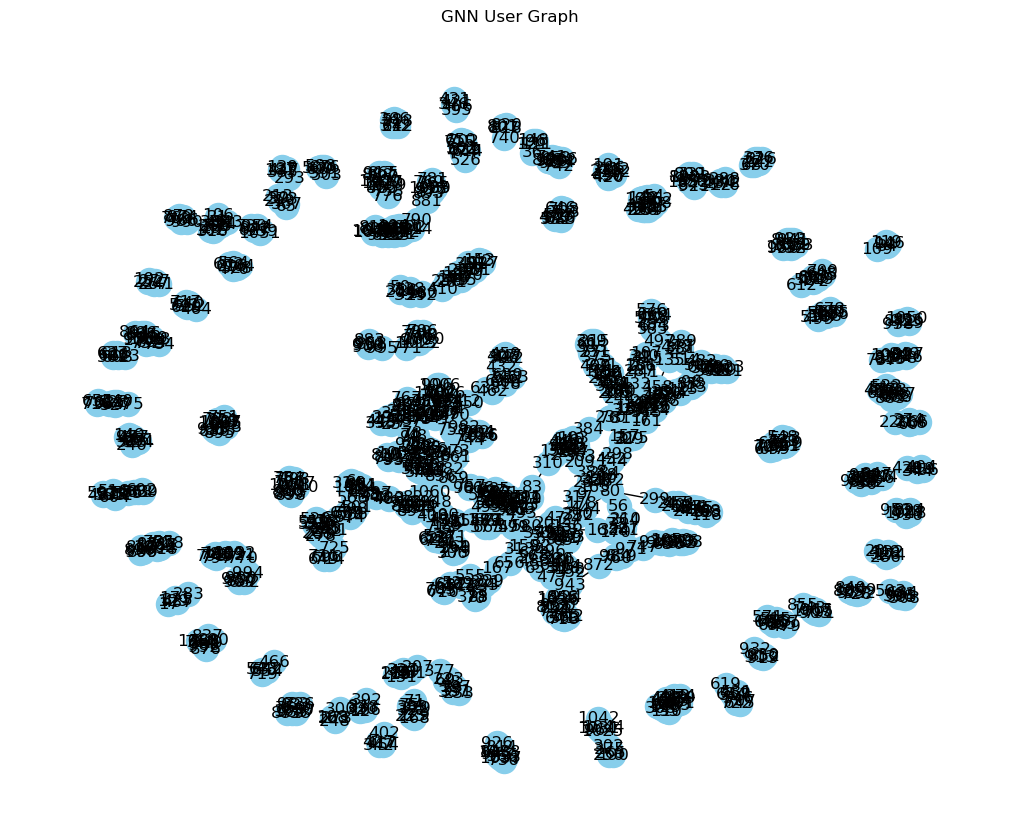

In [73]:
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_size=300, node_color='skyblue')
plt.title("GNN User Graph")
plt.show()

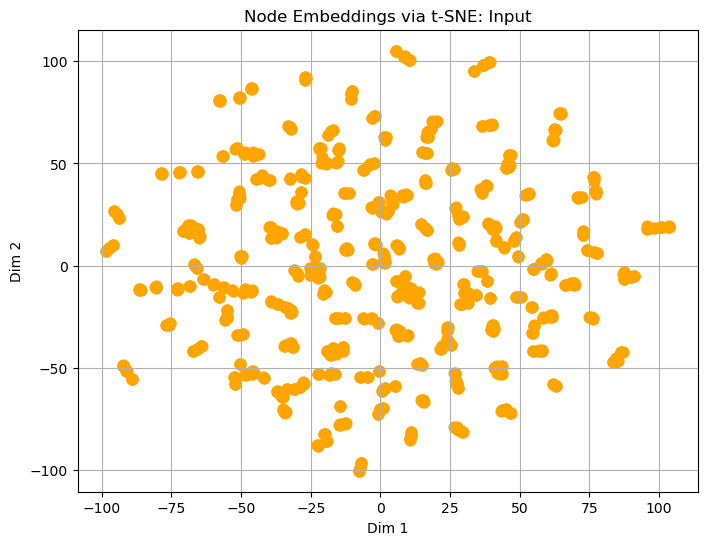

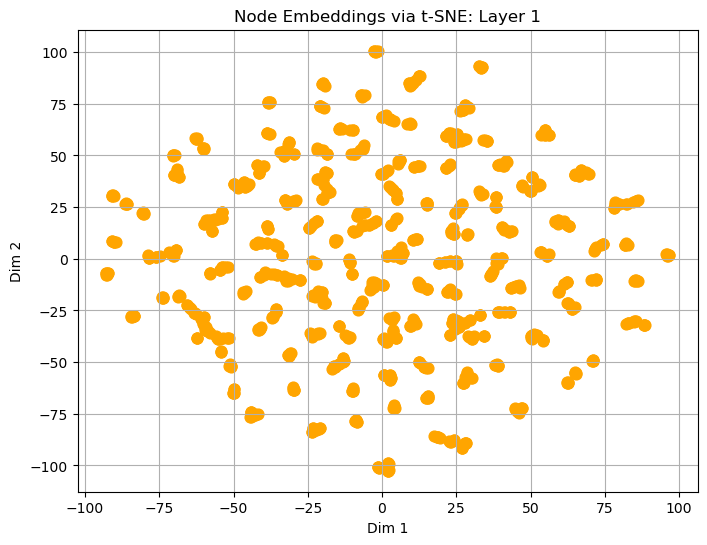

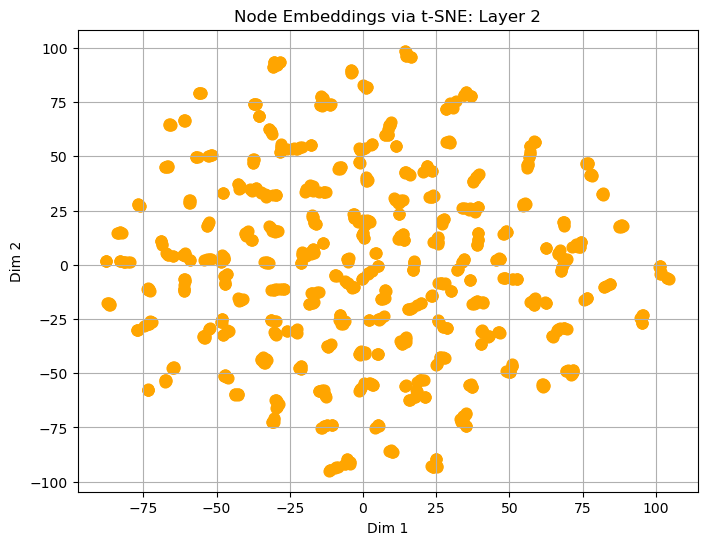

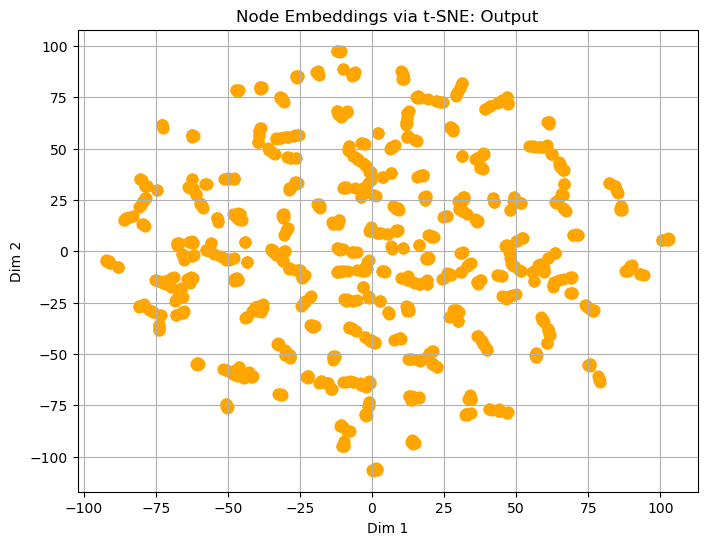

In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch

def plot_layer_embeddings(model, data, layer_names=['Input', 'Layer 1', 'Layer 2', 'Output']):
    model.eval()
    x = data.x
    edge_index = data.edge_index

    # Ensure tensor is on CPU for numpy conversion
    if x.is_cuda:
        x = x.cpu()
        edge_index = edge_index.cpu()

    # Check input dimension
    input_dim = model.conv1.in_channels
    if x.shape[1] != input_dim:
        raise ValueError(f"Model expects {input_dim} features, but got {x.shape[1]}.")

    embeddings = [x.numpy()]  # Input features

    # Layer 1
    x1 = model.conv1(x, edge_index)
    x1_relu = F.relu(x1)
    embeddings.append(x1_relu.detach().cpu().numpy())

    # Layer 2
    x2 = model.conv2(x1_relu, edge_index)
    x2_relu = F.relu(x2)
    embeddings.append(x2_relu.detach().cpu().numpy())

    # Output layer
    out = model.out(x2_relu, edge_index)
    embeddings.append(out.detach().cpu().numpy())

    # Plot t-SNE for each layer
    for i, emb in enumerate(embeddings):
        tsne = TSNE(n_components=2, perplexity=5, random_state=42)
        emb_2d = tsne.fit_transform(emb)
        plt.figure(figsize=(8, 6))
        plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='orange', s=60)
        plt.title(f"Node Embeddings via t-SNE: {layer_names[i]}")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.grid(True)
        plt.show()

# Usage:
plot_layer_embeddings(model, data)

#### Define GCN model

In [75]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = GCNConv(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        return self.out(x, edge_index)


### Train the model

##### Create Train/Validation Masks

In [76]:
from sklearn.model_selection import train_test_split

indices = list(range(len(X)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_mask = torch.zeros(len(X), dtype=torch.bool)
val_mask = torch.zeros(len(X), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask

#### Train the Model

In [77]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(x.shape[1], 64, y.shape[1]).to(device)
data = data.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.MSELoss()

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        val_out = model(data.x, data.edge_index)
        val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")


Epoch 0 | Train Loss: 1.2050 | Val Loss: 1.2698
Epoch 10 | Train Loss: 0.8603 | Val Loss: 0.8810
Epoch 20 | Train Loss: 0.6979 | Val Loss: 0.6965
Epoch 30 | Train Loss: 0.5959 | Val Loss: 0.5807
Epoch 40 | Train Loss: 0.5301 | Val Loss: 0.5074
Epoch 50 | Train Loss: 0.4950 | Val Loss: 0.4637
Epoch 60 | Train Loss: 0.4616 | Val Loss: 0.4352
Epoch 70 | Train Loss: 0.4362 | Val Loss: 0.4148
Epoch 80 | Train Loss: 0.4166 | Val Loss: 0.3993
Epoch 90 | Train Loss: 0.4192 | Val Loss: 0.3840
Epoch 100 | Train Loss: 0.3954 | Val Loss: 0.3716
Epoch 110 | Train Loss: 0.3922 | Val Loss: 0.3603
Epoch 120 | Train Loss: 0.3773 | Val Loss: 0.3513
Epoch 130 | Train Loss: 0.3696 | Val Loss: 0.3446
Epoch 140 | Train Loss: 0.3768 | Val Loss: 0.3389
Epoch 150 | Train Loss: 0.3573 | Val Loss: 0.3322
Epoch 160 | Train Loss: 0.3530 | Val Loss: 0.3277
Epoch 170 | Train Loss: 0.3468 | Val Loss: 0.3240
Epoch 180 | Train Loss: 0.3444 | Val Loss: 0.3203
Epoch 190 | Train Loss: 0.3432 | Val Loss: 0.3157
Epoch 200 |

### Evaluate Model Performance

In [78]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
preds = model(data.x, data.edge_index).detach().cpu().numpy()
true = data.y.detach().cpu().numpy()

# Inverse transform the predictions
preds = scaler_y.inverse_transform(preds)
true = scaler_y.inverse_transform(true)

print("MAE:", mean_absolute_error(true, preds))
print("RMSE:", mean_squared_error(true, preds, squared=False))
print("R² Score:", r2_score(true, preds))


MAE: 19.888275
RMSE: 26.54704
R² Score: 0.7486096732380191


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### Predict nutrient needs


In [79]:
model.eval()
predictions = model(data.x, data.edge_index).detach().cpu().numpy()
predicted_nutrition = pd.DataFrame(predictions, columns=target_cols)
print("\nPredicted Nutritional Needs:")
print(predicted_nutrition.head())


Predicted Nutritional Needs:
   Protein_Intake  Fat_Intake  Carbohydrate_Consumption  NutritionRisk  \
0       -1.070683    0.123455                 -0.266446       0.794077   
1       -0.367258    0.053200                 -0.432090      -0.787905   
2        0.051189    0.031612                 -0.941283      -1.969398   
3        0.405911    0.006892                  0.096315      -0.398309   
4        0.397824   -0.232269                 -0.380685      -1.495296   

   DiabetesRisk  Sugar_Consumption  Caloric_Balance  
0     -1.022368          -1.033953         0.111071  
1     -0.843806          -0.697097        -0.034976  
2     -1.522288          -0.794190        -0.477670  
3     -0.942147          -0.086182        -1.247874  
4     -1.065179           0.163948        -0.226236  


#### Visualize node embeddings

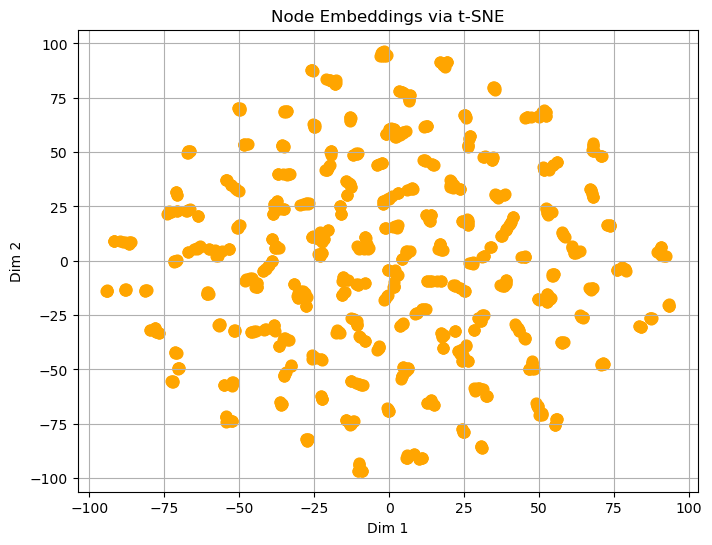

In [80]:
with torch.no_grad():
    embeddings = model.conv1(data.x, data.edge_index).cpu().numpy()

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='orange', s=60)
plt.title("Node Embeddings via t-SNE")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

#### Food recommendation function

In [81]:
def recommend_foods(protein_target, fat_target, carbs_target, top_n=5):
    food_df_clean = food_df.copy()
    # Ensure correct columns and numeric types
    food_df_clean[['Protein_(g)', 'Fat_(g)', 'Carbohydrate_(g)']] = food_df_clean[
        ['Protein_(g)', 'Fat_(g)', 'Carbohydrate_(g)']
    ].apply(pd.to_numeric, errors='coerce').fillna(0)

    food_df_clean['score'] = (
        abs(food_df_clean['Protein_(g)'] - protein_target) +
        abs(food_df_clean['Fat_(g)'] - fat_target) +
        abs(food_df_clean['Carbohydrate_(g)'] - carbs_target)
    )

    return food_df_clean.sort_values('score').head(top_n)

 #### Recommend foods for the first user

In [82]:
first_user_pred = predicted_nutrition.iloc[0]
recommended = recommend_foods(
    protein_target=first_user_pred['Protein_Intake'],
    fat_target=first_user_pred['Fat_Intake'],
    carbs_target=first_user_pred['Carbohydrate_Consumption']
)

print("\nRecommended Foods for User 1:")
print(recommended[['Food', 'Category', 'Recipe/Single_food_item', 'Quantity', 'Carbohydrate_(g)', 'Protein_(g)', 'Fat_(g)', 'Calories_(kcal)']])


Recommended Foods for User 1:
                                        Food   Category  \
893                           VEGETABLE SOUP    Dessert   
264                           CUCUMBER SALAD    Dessert   
3                                    ALMONDS  Breakfast   
424                                  HOPPERS    Dessert   
285  DRINKING YOGHURT, FLAVORED OR SWEETENED  Breakfast   

    Recipe/Single_food_item  Quantity  Carbohydrate_(g)  Protein_(g)  Fat_(g)  \
893                       R     100.0              6.00         1.50      0.3   
264                       R     100.0              7.00         1.00      0.0   
3                         S      30.0              6.00         6.00     15.0   
424                       R      30.0             20.00         3.00      4.0   
285                       S      92.0             22.68         2.14      2.9   

     Calories_(kcal)  
893             30.0  
264             35.0  
3              180.0  
424            120.0  
285         

#### Meal portion splits (total = 1.0)

In [83]:
meal_ratios = {
    'breakfast': 0.25,
    'lunch': 0.30,
    'dinner': 0.30,
    'snack': 0.15
}

#### Build 7-day meal plan for a user

In [89]:
def generate_meal_plan(user_pred, food_df, meals_per_day=['breakfast', 'lunch', 'dinner', 'snack']):
    plan = {}
    # Map meal to food category (adjust these strings to match your dataset's Category values)
    meal_category_map = {
        'breakfast': 'Breakfast',
        'lunch': 'Lunch',
        'dinner': 'Dinner',
        'snack': 'Snack'
    }
    daily_targets = {
        'breakfast': 0.25,
        'lunch': 0.35,
        'dinner': 0.30,
        'snack': 0.10
    }

    for day in range(1, 8):
        day_plan = {}
        for meal in meals_per_day:
            ratio = daily_targets[meal]
            protein_target = user_pred['Protein_Intake'] * ratio
            fat_target = user_pred['Fat_Intake'] * ratio
            carbs_target = user_pred['Carbohydrate_Consumption'] * ratio

            # Filter foods by category for the current meal
            category = meal_category_map[meal]
            food_df_filtered = food_df[food_df['Category'].str.lower() == category.lower()]

            # If no foods in this category, fallback to all foods
            if food_df_filtered.empty:
                food_df_filtered = food_df

            # Use only filtered foods for recommendation
            recommended_meals = recommend_foods(protein_target, fat_target, carbs_target, top_n=5)
            recommended_meals = food_df_filtered.loc[recommended_meals.index.intersection(food_df_filtered.index)]

            # If no intersection, fallback to top from filtered
            if recommended_meals.empty:
                recommended_meals = food_df_filtered.head(5)

            chosen = recommended_meals.sample(1).iloc[0]

            # Calculate coverage
            protein_covered = chosen['Protein_(g)'] / protein_target if protein_target else 0
            fat_covered = chosen['Fat_(g)'] / fat_target if fat_target else 0
            carbs_covered = chosen['Carbohydrate_(g)'] / carbs_target if carbs_target else 0

            day_plan[meal] = {
                'Food': chosen['Food'],
                'Category': chosen['Category'],
                'Recipe/Single_food_item': chosen['Recipe/Single_food_item'],
                'Quantity': chosen['Quantity'],
                'Carbohydrate_(g)': chosen['Carbohydrate_(g)'],
                'Protein_(g)': chosen['Protein_(g)'],
                'Fat_(g)': chosen['Fat_(g)'],
                'Calories_(kcal)': chosen['Calories_(kcal)'],
                'Protein_Coverage_%': round(protein_covered * 100, 1),
                'Fat_Coverage_%': round(fat_covered * 100, 1),
                'Carbs_Coverage_%': round(carbs_covered * 100, 1),
                'Protein_Target': round(protein_target, 2),
                'Fat_Target': round(fat_target, 2),
                'Carbs_Target': round(carbs_target, 2)
            }
        plan[f'Day {day}'] = day_plan
    return plan

# Generate meal plan for first user
meal_plan = generate_meal_plan(first_user_pred, food_df)

from pprint import pprint
print("\n7-Day Meal Plan for User 1 (with coverage % and targets):")
pprint(meal_plan)


7-Day Meal Plan for User 1 (with coverage % and targets):
{'Day 1': {'breakfast': {'Calories_(kcal)': 180.0,
                         'Carbohydrate_(g)': 6.0,
                         'Carbs_Coverage_%': -9007.4,
                         'Carbs_Target': -0.07,
                         'Category': 'Breakfast',
                         'Fat_(g)': 15.0,
                         'Fat_Coverage_%': 48600.6,
                         'Fat_Target': 0.03,
                         'Food': 'ALMONDS',
                         'Protein_(g)': 6.0,
                         'Protein_Coverage_%': -2241.6,
                         'Protein_Target': -0.27,
                         'Quantity': 30.0,
                         'Recipe/Single_food_item': 'S'},
           'dinner': {'Calories_(kcal)': 232.6,
                      'Carbohydrate_(g)': 22.68,
                      'Carbs_Coverage_%': -28373.4,
                      'Carbs_Target': -0.08,
                      'Category': 'Breakfast',
            

In [87]:
y_true = y  # shape: (num_samples, num_targets)
y_pred = predicted_nutrition.values  # shape: (num_samples, num_targets)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

#### Generate plan for first user